# Monte Carlo Simulation

Monte Carlo simulation uses random sampling to estimate a range of possible future outcomes.

Abbreviations used in this notebook:

- **GBM**: Geometric Brownian Motion.
- **VaR**: Value at Risk.
- **CVaR**: Conditional Value at Risk.
- **P5/P50/P95**: 5th, 50th, and 95th percentiles.
- **PDF**: Probability Density Function, useful for interpreting simulated distributions.

## 1. Intuition

Instead of forecasting one future path, Monte Carlo simulation generates many possible paths. This helps us understand upside, downside, and the probability of failing to reach a goal.

## 2. Mathematics

Geometric Brownian Motion:

$$
S_{t+1} = S_t \times e^{(\mu - \frac{1}{2}\sigma^2)\Delta t + \sigma\sqrt{\Delta t}Z_t}
$$

Where $Z_t$ is a random draw from a standard normal distribution.

Terminal return:

$$
R_T = \frac{S_T}{S_0} - 1
$$

## 3. Implementation

We simulate one-year price paths for a risky asset using GBM.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "04_quantitative_methods" / "quant_utils.py"
spec = importlib.util.spec_from_file_location("quant_utils", helper_path)
quant_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(quant_utils)

plt.style.use("seaborn-v0_8-whitegrid")
returns = quant_utils.generate_return_sample()

paths = quant_utils.simulate_gbm_paths(start_value=100, annual_return=0.07, annual_volatility_value=0.16, years=1, paths=3000, seed=808)
terminal_values = paths.iloc[-1]
terminal_returns = terminal_values / paths.iloc[0] - 1

simulation_summary = pd.Series({
    "mean_terminal_value": terminal_values.mean(),
    "median_terminal_value": terminal_values.median(),
    "p5_terminal_value": terminal_values.quantile(0.05),
    "p95_terminal_value": terminal_values.quantile(0.95),
    "probability_loss": (terminal_returns < 0).mean(),
    "terminal_var_5pct": -terminal_returns.quantile(0.05),
})
simulation_summary.to_frame("value")

,value
mean_terminal_value,107.259688
median_terminal_value,105.896553
p5_terminal_value,82.147841
p95_terminal_value,137.637328
probability_loss,0.362333
terminal_var_5pct,0.178522


## 4. Visualization

Monte Carlo output is best read through path samples and terminal distributions.

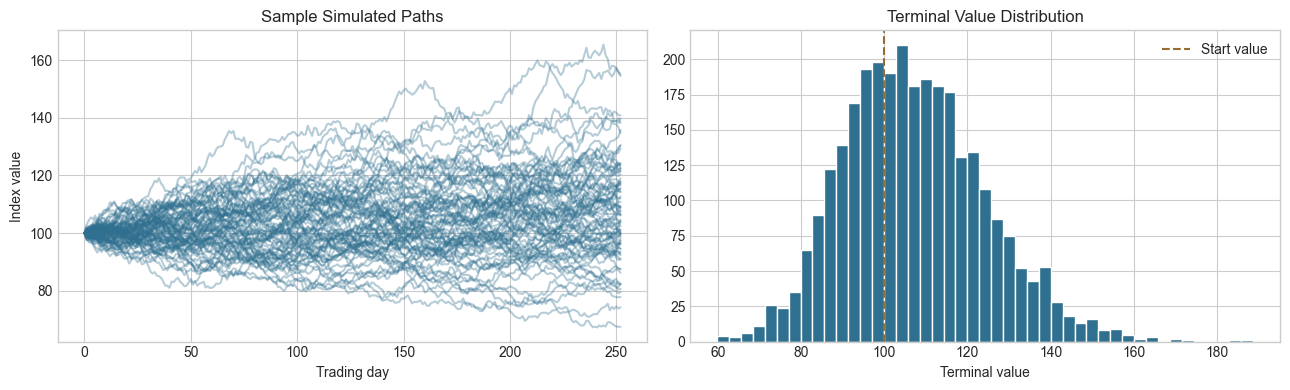

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
paths.iloc[:, :80].plot(ax=axes[0], legend=False, alpha=0.35, color="#2f6f8f")
axes[0].set_title("Sample Simulated Paths")
axes[0].set_xlabel("Trading day")
axes[0].set_ylabel("Index value")

terminal_values.hist(bins=45, ax=axes[1], color="#2f6f8f", edgecolor="white")
axes[1].axvline(100, color="#9a6b2f", linestyle="--", label="Start value")
axes[1].set_title("Terminal Value Distribution")
axes[1].set_xlabel("Terminal value")
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Application

Monte Carlo simulation is useful for retirement planning, risk limits, option intuition, portfolio goal analysis, and stress testing.

In [3]:
goal_value = 110
print(f"Probability terminal value exceeds {goal_value}: {(terminal_values > goal_value).mean():.1%}")
print(f"Probability of losing money: {(terminal_values < 100).mean():.1%}")
print(f"Expected shortfall below 5th percentile: {-terminal_returns[terminal_returns <= terminal_returns.quantile(0.05)].mean():.1%}")

Probability terminal value exceeds 110: 41.2%
Probability of losing money: 36.2%
Expected shortfall below 5th percentile: 24.0%


## 6. Reflection

- Monte Carlo turns assumptions into distributions.
- Simulation quality depends entirely on model assumptions.
- More paths reduce simulation noise but do not fix a bad model.
- Tail outcomes are often more important than the average outcome.

Questions to answer after running the notebook:

1. What is the probability of losing money?
2. How wide is the terminal value range?
3. What assumptions drive the simulation most?
4. Why is GBM only a simplified model of markets?